# 03 · Walk-forward y sobreajuste

**Objetivo:** ver por qué una estrategia optimizada sobre todo el histórico parece mucho mejor de lo que es, y obtener la única curva "honesta": la del walk-forward.

**Necesitas:** todo lo anterior y los TODO 5.x. Checkpoint: `python -m pytest tests/test_walkforward.py`.

**Teoría:** `docs/05_Walk_forward_y_sobreajuste.pdf`.

**Cómo usar este notebook.** Ejecuta las celdas en orden. Una celda que llama a una función que todavía es un TODO falla con `NotImplementedError: TODO x.y`: completa ese TODO, pasa su checkpoint de `pytest` y vuelve a ejecutarla (con `autoreload` no hace falta reiniciar el kernel).

Las celdas marcadas **`# TODO (análisis)`** son tuyas y no las corrige ningún test: sirven para mirar los datos y responder a las preguntas. Hasta que las completes no hacen nada (`...`).

In [1]:
# Configuración: localiza la raíz del repo y recarga src/ al guardar cambios (no hace falta reiniciar)
%load_ext autoreload
%autoreload 2

import json
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from src import backtest, config, data, metrics, plotting, strategies, walkforward

plotting.apply_style()
pd.set_option("display.width", 140)

In [2]:
prices = data.load_prices()
sma = strategies.sma_crossover
sma_grid = walkforward.expand_grid(config.PARAM_GRIDS["sma_crossover"], config.PARAM_CONSTRAINTS["sma_crossover"])
boll = strategies.bollinger_mean_reversion
boll_grid = walkforward.expand_grid(config.PARAM_GRIDS["bollinger_mean_reversion"])
print(f"{len(sma_grid)} combinaciones para el cruce de medias, {len(boll_grid)} para Bollinger")

17 combinaciones para el cruce de medias, 16 para Bollinger


## 1. Ventanas

3 años de entrenamiento, 1 de test, paso anual (`config.WF_*`).

train [2010-01-04, 2013-01-04)  test [2013-01-04, 2014-01-04)
train [2011-01-04, 2014-01-04)  test [2014-01-04, 2015-01-04)
train [2012-01-04, 2015-01-04)  test [2015-01-04, 2016-01-04)
train [2013-01-04, 2016-01-04)  test [2016-01-04, 2017-01-04)
train [2014-01-04, 2017-01-04)  test [2017-01-04, 2018-01-04)
train [2015-01-04, 2018-01-04)  test [2018-01-04, 2019-01-04)
train [2016-01-04, 2019-01-04)  test [2019-01-04, 2020-01-04)
train [2017-01-04, 2020-01-04)  test [2020-01-04, 2021-01-04)
train [2018-01-04, 2021-01-04)  test [2021-01-04, 2022-01-04)
train [2019-01-04, 2022-01-04)  test [2022-01-04, 2023-01-04)
train [2020-01-04, 2023-01-04)  test [2023-01-04, 2024-01-04)
train [2021-01-04, 2024-01-04)  test [2024-01-04, 2025-01-04)
train [2022-01-04, 2025-01-04)  test [2025-01-04, 2026-01-04)
train [2023-01-04, 2026-01-04)  test [2026-01-04, 2027-01-04)


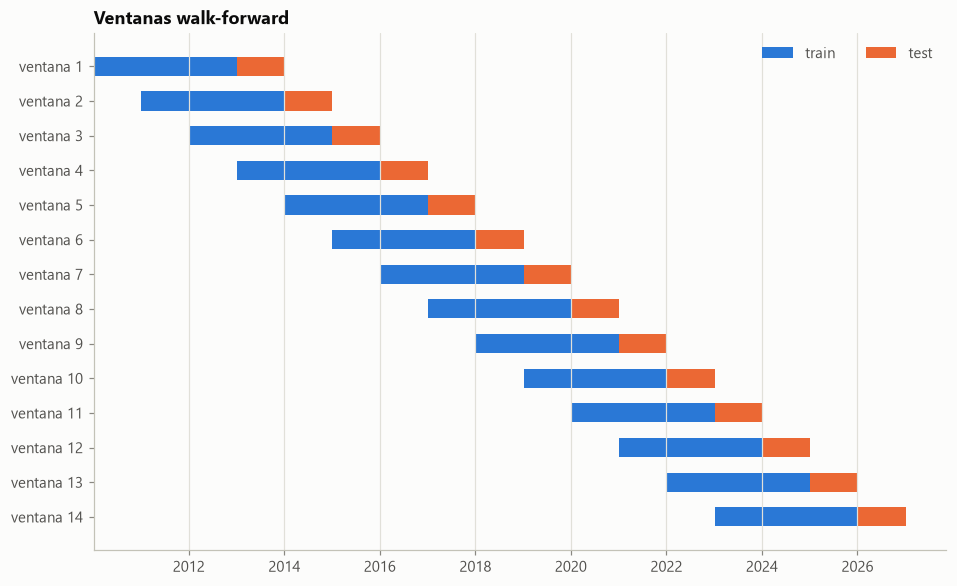

In [3]:
windows = walkforward.generate_windows(prices.index)
for w in windows:
    print(w)
plotting.plot_wf_windows(windows);

## 2. Walk-forward del cruce de medias

En cada ventana se elige la combinación con mejor Sharpe *en train* y se aplica en el año de test. Tarda unos segundos.

In [4]:
wf_sma = walkforward.walk_forward(prices, sma, sma_grid)
wf_sma.selections

,train_start,test_start,test_end,fast,slow,train_sharpe
0,2010-01-04,2013-01-04,2014-01-04,50,150,0.992556
1,2011-01-04,2014-01-04,2015-01-04,50,150,1.140411
2,2012-01-04,2015-01-04,2016-01-04,20,250,1.475363
3,2013-01-04,2016-01-04,2017-01-04,50,150,1.166359
4,2014-01-04,2017-01-04,2018-01-04,100,150,1.101595
5,2015-01-04,2018-01-04,2019-01-04,100,150,1.555605
6,2016-01-04,2019-01-04,2020-01-04,20,50,1.170268
7,2017-01-04,2020-01-04,2021-01-04,50,100,1.445252
8,2018-01-04,2021-01-04,2022-01-04,20,50,1.276090
9,2019-01-04,2022-01-04,2023-01-04,10,200,1.697266


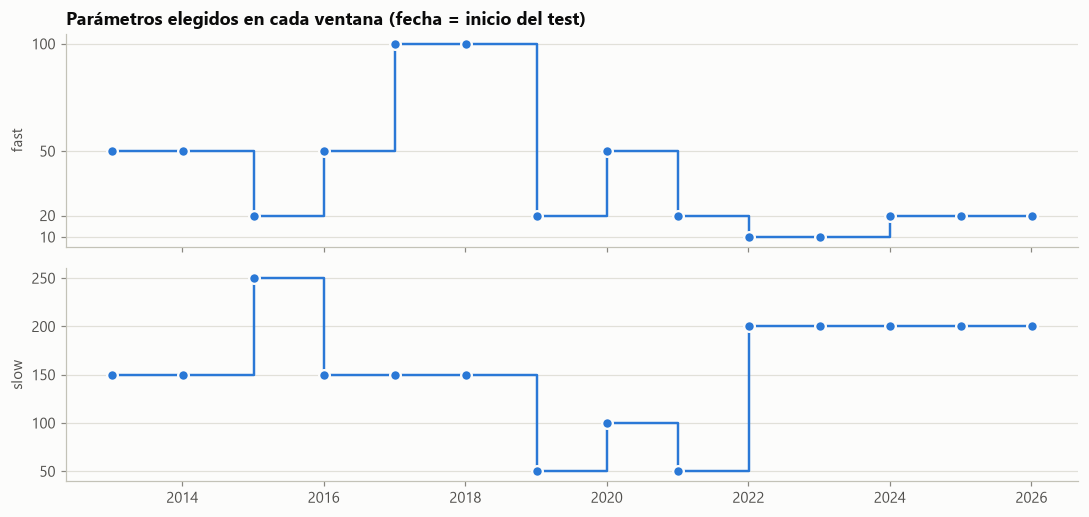

In [5]:
plotting.plot_param_stability(wf_sma.selections, ["fast", "slow"]);

> **Pregunta.** Si los parámetros "buenos" cambian casi cada año, ¿qué te dice eso sobre la idea de que existe *un* parámetro óptimo?

## 3. Mapas de calor: ¿la zona buena es estable?

Sharpe en train de cada combinación, en tres ventanas distintas. El recuadro es la combinación elegida.

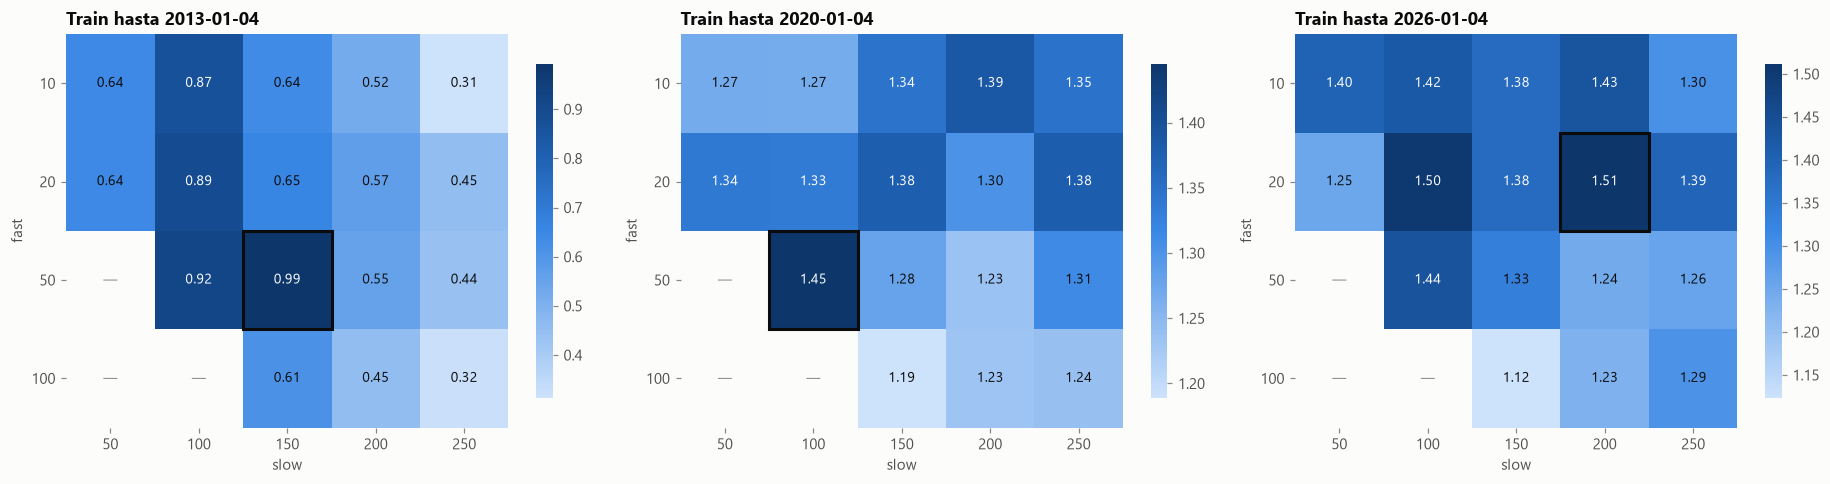

In [6]:
picks = [0, len(wf_sma.searches) // 2, len(wf_sma.searches) - 1]
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
for ax, k in zip(axes, picks):
    search = wf_sma.searches[k]
    heat = walkforward.heatmap_table(search, "fast", "slow")
    best = (search.best_params["fast"], search.best_params["slow"])
    plotting.plot_sharpe_heatmap(heat, title=f"Train hasta {wf_sma.windows[k].train_end:%Y-%m-%d}", best=best, ax=ax)
fig.tight_layout()

## 4. Tres curvas sobre el mismo periodo fuera de muestra

- **Parámetros fijos:** los de libro (50/200), decididos sin mirar los datos.
- **Optimizado in-sample:** los mejores parámetros de *todo* el histórico. Es trampa: para elegirlos se ha usado el futuro.
- **Walk-forward:** cada año, solo con el pasado.

Las tres se comparan en el mismo periodo: desde el primer año de test hasta hoy.

In [7]:
oos_start = wf_sma.result.returns.index[0]
fixed = backtest.run_backtest(prices, sma(prices, **config.STRATEGY_DEFAULTS["sma_crossover"])).slice(oos_start, None)
print(f"Periodo fuera de muestra: {oos_start:%Y-%m-%d} a {prices.index[-1]:%Y-%m-%d}")

Periodo fuera de muestra: 2013-01-04 a 2026-10-07


In [8]:
# TODO (análisis): la curva "tramposa".
# 1) grid_search sobre Todo el histórico: de prices.index[0] a prices.index[-1] + 1 día (el fin es exclusivo).
# 2) Backtest con los mejores parámetros y recorte al periodo fuera de muestra con .slice(oos_start, None).
# Guarda el BacktestResult recortado en `insample`.

start = prices.index[0]
end = prices.index[-1] + pd.Timedelta(days=1)
full_search = walkforward.grid_search(prices, sma, sma_grid, start, end)
print("Mejores parámetros con todo el histórico:", full_search.best_params)

best_signals = sma(prices, **full_search.best_params)
backtest_result = backtest.run_backtest(prices, best_signals)
insample = backtest_result.slice(oos_start, None) 

Mejores parámetros con todo el histórico: {'fast': 10, 'slow': 200}


,CAGR,Vol.,Sharpe,Sortino,Max DD,Calmar,Hit ratio,Turnover anual
Estrategia,,,,,,,,
parámetros fijos (50/200),10.6%,10.6%,1.00,1.38,-22.9%,0.46,55.8%,1.2×
optimizado in-sample (trampa),11.3%,9.2%,1.21,1.70,-14.2%,0.80,55.4%,2.4×
walk-forward,9.5%,9.9%,0.97,1.33,-20.0%,0.48,55.2%,2.5×


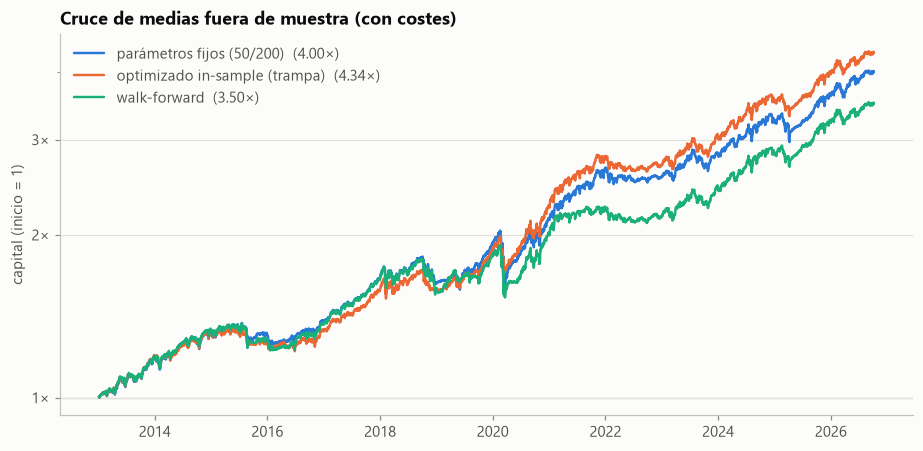

In [9]:
curves = {"parámetros fijos (50/200)": fixed}
if isinstance(insample, backtest.BacktestResult):
    curves["optimizado in-sample (trampa)"] = insample
curves["walk-forward"] = wf_sma.result
plotting.plot_equity(curves, title="Cruce de medias fuera de muestra (con costes)")
metrics.format_summary(metrics.summary_table(curves))

> **Preguntas.** ¿Cuál es la mejor curva? ¿Podrías haberla obtenido en tiempo real? ¿Cuánto Sharpe "desaparece" al pasar de in-sample a walk-forward? ¿Y frente a los parámetros fijos?

## 5. Lo mismo con Bollinger

Mejores parámetros con todo el histórico: {'window': 40, 'n_std': 2.0}


,CAGR,Vol.,Sharpe,Sortino,Max DD,Calmar,Hit ratio,Turnover anual
Estrategia,,,,,,,,
"parámetros fijos (20, 2σ)",4.2%,9.2%,0.49,0.71,-25.0%,0.17,50.8%,8.7×
optimizado in-sample (trampa),4.1%,9.1%,0.49,0.72,-24.8%,0.17,51.8%,4.7×
walk-forward,3.4%,9.3%,0.41,0.60,-23.5%,0.15,49.1%,6.8×


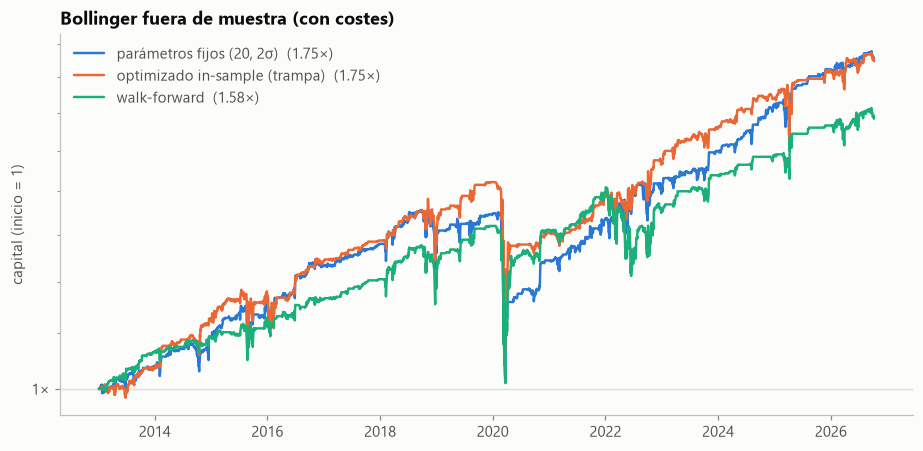

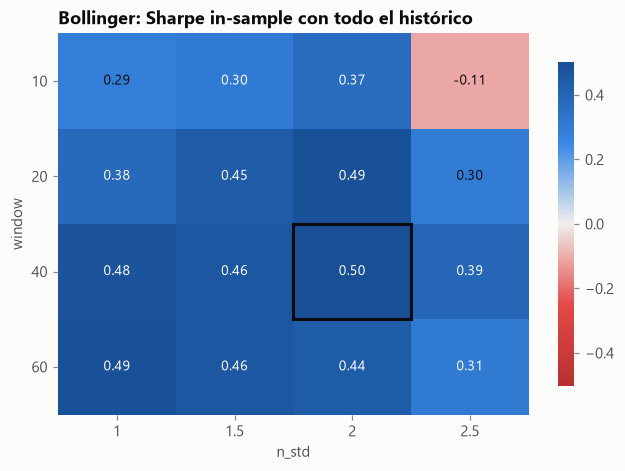

In [10]:
# TODO (análisis): repite el análisis para Bollinger (boll, boll_grid):
#   - walk-forward
#   - parámetros fijos (config.STRATEGY_DEFAULTS["bollinger_mean_reversion"]) recortados a oos_start
#   - optimizado in-sample recortado a oos_start
#   - curvas + tabla, y el mapa de calor del grid_search sobre todo el histórico ("window" × "n_std")

wf_boll = walkforward.walk_forward(prices, boll, boll_grid)

boll_fixed = backtest.run_backtest(
    prices, boll(prices, **config.STRATEGY_DEFAULTS["bollinger_mean_reversion"])
).slice(oos_start, None)

boll_full = walkforward.grid_search(prices, boll, boll_grid, prices.index[0], prices.index[-1] + pd.Timedelta(days=1))
print("Mejores parámetros con todo el histórico:", boll_full.best_params)
boll_insample = backtest.run_backtest(prices, boll(prices, **boll_full.best_params)).slice(oos_start, None)

boll_curves = {
    "parámetros fijos (20, 2σ)": boll_fixed,
    "optimizado in-sample (trampa)": boll_insample,
    "walk-forward": wf_boll.result,
}
plotting.plot_equity(boll_curves, title="Bollinger fuera de muestra (con costes)")
display(metrics.format_summary(metrics.summary_table(boll_curves)))

best = (boll_full.best_params["window"], boll_full.best_params["n_std"])
plotting.plot_sharpe_heatmap(
    walkforward.heatmap_table(boll_full, "window", "n_std"),
    title="Bollinger: Sharpe in-sample con todo el histórico",
    best=best,
);


## 6. Resultados para el README

Tabla con las filas del README, todas sobre el mismo periodo fuera de muestra y con costes. Copia la tabla en la sección *Resultados* y enlaza la imagen (`docs/img/equity.png`).

In [11]:
final = {
    "Buy & Hold": backtest.run_backtest(prices, strategies.buy_and_hold(prices)).slice(oos_start, None),
    "Momentum (cruce MM)": fixed,
    "Momentum 12m": backtest.run_backtest(prices, strategies.momentum_12m(prices)).slice(oos_start, None),
    "Mean reversion (Bollinger)": backtest.run_backtest(
        prices, boll(prices, **config.STRATEGY_DEFAULTS["bollinger_mean_reversion"])
    ).slice(oos_start, None),
    "Walk-forward": wf_sma.result,
}
final_table = metrics.summary_table(final)
print(f"Periodo: {oos_start:%Y-%m-%d} a {prices.index[-1]:%Y-%m-%d}, con costes de 5 + 5 bps\n")
print(metrics.to_markdown_table(final_table))

Periodo: 2013-01-04 a 2026-10-07, con costes de 5 + 5 bps

| Estrategia | CAGR | Vol. | Sharpe | Sortino | Max DD | Calmar | Hit ratio | Turnover anual |
|---|---|---|---|---|---|---|---|---|
| Buy & Hold | 15.0% | 14.4% | 1.04 | 1.49 | -28.3% | 0.53 | 54.9% | 0.0× |
| Momentum (cruce MM) | 10.6% | 10.6% | 1.00 | 1.38 | -22.9% | 0.46 | 55.8% | 1.2× |
| Momentum 12m | 10.3% | 10.9% | 0.95 | 1.34 | -20.4% | 0.50 | 55.8% | 1.2× |
| Mean reversion (Bollinger) | 4.2% | 9.2% | 0.49 | 0.71 | -25.0% | 0.17 | 50.8% | 8.7× |
| Walk-forward | 9.5% | 9.9% | 0.97 | 1.33 | -20.0% | 0.48 | 55.2% | 2.5× |


Guardado en docs\img\equity.png


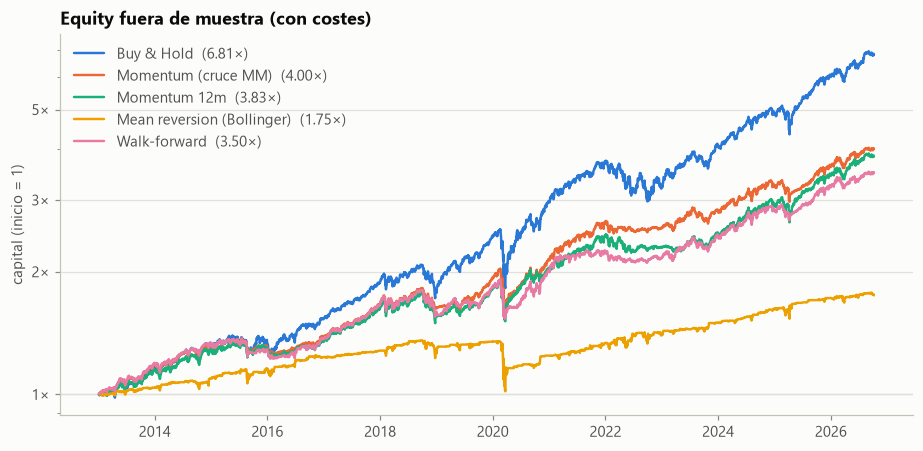

In [12]:
img_dir = config.ROOT / "docs" / "img"
img_dir.mkdir(parents=True, exist_ok=True)
ax = plotting.plot_equity(final, title="Equity fuera de muestra (con costes)")
ax.figure.savefig(img_dir / "equity.png", dpi=150, bbox_inches="tight")
print("Guardado en", (img_dir / "equity.png").relative_to(config.ROOT))

## 7. Preguntas de reflexión

1. **Data snooping.** Has probado 17 combinaciones de medias y 16 de Bollinger. Si probaras 1000, ¿qué le pasaría al mejor Sharpe in-sample aunque ninguna estrategia tuviera ventaja real?
2. **El walk-forward también se puede sobreajustar.** Si cambias la rejilla, la métrica o la longitud de las ventanas hasta que la curva walk-forward quede bonita, ¿sigue siendo honesta?
3. **Ventanas.** ¿Qué esperas que pase con 1 año de train en vez de 3? ¿Y con 8? Pruébalo con `train_years`.
4. **Métrica de selección.** Cambia `metric="sharpe"` por `"calmar"` o `"cagr"`. ¿Cambian mucho los parámetros elegidos?
5. Escribe en la sección *Limitaciones* del README lo que has aprendido aquí.